### Summary:

This notebook performs a comparative analysis of different linear regression models, including standard Linear Regression (Ordinary Least Squares) and regularized variants (Ridge, Lasso, and Elastic Net), using the California Housing dataset.

**Here's a breakdown of the steps:**

1.  **Load Dataset:**
    *   It starts by loading the `fetch_california_housing` dataset from `sklearn.datasets`. This dataset contains various features of houses in California and a target variable representing their median house value.
    *   It also includes commented-out sections for loading a custom CSV file, demonstrating flexibility for different data sources.
    *   Missing values in the features (`X`) are handled by imputing them with the mean of their respective columns.

2.  **Prepare & Scale Data:**
    *   The dataset is split into training (80%) and testing (20%) sets using `train_test_split` to evaluate model performance on unseen data.
    *   Features are then scaled using `StandardScaler`. This is a crucial step for regularized models like Ridge, Lasso, and Elastic Net, as it ensures that all features contribute equally to the regularization penalty, preventing features with larger scales from dominating the process.

3.  **Define Models:**
    *   Four different regression models are initialized:
        *   **Linear Regression (OLS):** The basic linear model without regularization.
        *   **Ridge (L2 Regularization):** Applies L2 penalty, which shrinks coefficients towards zero, helping to prevent overfitting and improve generalization.
        *   **Lasso (L1 Regularization):** Applies L1 penalty, which can shrink some coefficients exactly to zero, effectively performing feature selection.
        *   **Elastic Net (L1 + L2):** Combines both L1 and L2 penalties, offering a balance between feature selection and coefficient shrinkage.
    *   `alpha=0.1` is used as a balanced starting regularization strength for Ridge, Lasso, and Elastic Net.

4.  **Train and Evaluate Models:**
    *   Each defined model is trained on the scaled training data (`X_train_scaled`, `y_train`).
    *   Predictions are then made on the scaled test data (`X_test_scaled`).
    *   The performance of each model is evaluated using two metrics:
        *   **Mean Squared Error (MSE):** Measures the average squared difference between the actual and predicted values.
        *   **R2 Score (Coefficient of Determination):** Represents the proportion of variance in the dependent variable that can be predicted from the independent variables.
    *   The results and model coefficients are stored for later analysis.

5.  **Detect Dropped Features:**
    *   This section specifically analyzes the coefficients of the models to identify how many features each regularized model effectively


--- REAL DATASET PERFORMANCE COMPARISON ---
                           Test MSE  R2 Score
Linear Regression (OLS)      0.5559    0.5758
Ridge (L2 Regularization)    0.5559    0.5758
Lasso (L1 Regularization)    0.6796    0.4814
Elastic Net (L1 + L2)        0.6359    0.5148
-------------------------------------------

--- FEATURE SELECTION DEMONSTRATION ---
Linear Regression (OLS): Kept 8/8 features | Dropped 0
Ridge (L2 Regularization): Kept 8/8 features | Dropped 0
Lasso (L1 Regularization): Kept 3/8 features | Dropped 5
Elastic Net (L1 + L2): Kept 4/8 features | Dropped 4
---------------------------------------



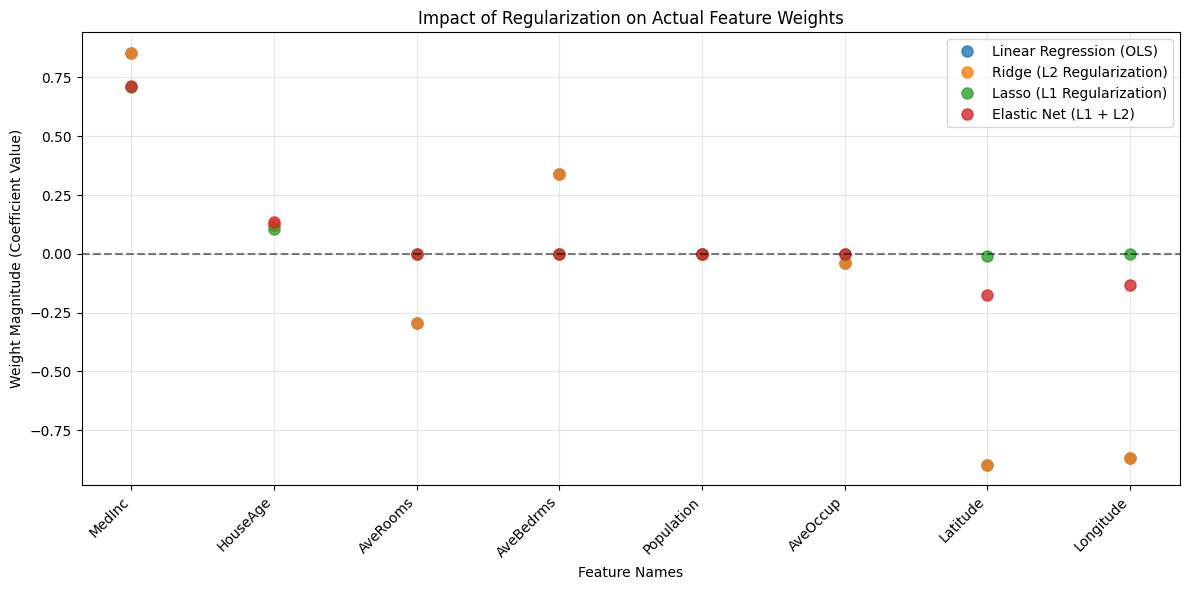

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Lasso, Ridge, ElasticNet
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.datasets import fetch_california_housing

# ==========================================
# 1. LOAD DATASET
# ==========================================
# Option A: Using a built-in real world dataset (California Housing)
data = fetch_california_housing(as_frame=True)
df = data.frame
X = df[data.feature_names]
y = df[data.target_names[0]]

# Option B: YOUR OWN DATASET (Uncomment the lines below to use your CSV)
# df = pd.read_csv("your_data_file.csv")
# X = df.drop(columns=["your_target_column_name"])
# y = df["your_target_column_name"]

# Handle any missing values if using a custom CSV
X = X.fillna(X.mean())

# ==========================================
# 2. PREPARE & SCALE
# ==========================================
# Split into training and testing sets (80/20 split)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scale Features (CRITICAL: Prevents large-scale columns from dominating penalties)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# ==========================================
# 3. DEFINE MODELS
# ==========================================
# alpha=0.1 provides a balanced starting regularization strength for real data
models = {
    "Linear Regression (OLS)": LinearRegression(),
    "Ridge (L2 Regularization)": Ridge(alpha=0.1),
    "Lasso (L1 Regularization)": Lasso(alpha=0.1),
    "Elastic Net (L1 + L2)": ElasticNet(alpha=0.1, l1_ratio=0.5)
}

# ==========================================
# 4. TRAIN AND EVALUATE
# ==========================================
results = {}
coefficients = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)

    results[name] = {
        "Test MSE": mean_squared_error(y_test, predictions),
        "R2 Score": r2_score(y_test, predictions)
    }
    coefficients[name] = model.coef_

# Display metrics table
df_metrics = pd.DataFrame(results).T
print("\n--- REAL DATASET PERFORMANCE COMPARISON ---")
print(df_metrics.round(4))
print("-------------------------------------------\n")

# ==========================================
# 5. DETECT DROPPED FEATURES
# ==========================================
print("--- FEATURE SELECTION DEMONSTRATION ---")
total_features = X.shape[1]
for name, coef in coefficients.items():
    zero_count = np.sum(np.isclose(coef, 0.0, atol=1e-4))
    print(f"{name}: Kept {total_features - zero_count}/{total_features} features | Dropped {zero_count}")
print("---------------------------------------\n")

# ==========================================
# 6. VISUALIZE COEFFICIENTS
# ==========================================
plt.figure(figsize=(12, 6))
feature_names = X.columns

for name, coef in coefficients.items():
    plt.plot(feature_names, coef, marker='o', linestyle='none', label=name, alpha=0.8, markersize=8)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.title("Impact of Regularization on Actual Feature Weights")
plt.xlabel("Feature Names")
plt.ylabel("Weight Magnitude (Coefficient Value)")
plt.xticks(rotation=45, ha='right')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## Linear regression to predict range of values

## Quantile Regression

Traditional Ordinary Least Squares (OLS) regression models focus on predicting the *conditional mean* of the target variable. This means OLS provides a single prediction that represents the average outcome. However, real-world data often exhibits **heteroscedasticity**, where the variability of the target changes across different ranges of the input features. For instance, in real estate, home prices in low-income areas might have a narrow, predictable range, while high-income areas show a vast divergence in property values (from luxury complexes to custom mansions). OLS struggles with this varying spread.

### The Quantile Regression Advantage

**Quantile regression** addresses this by shifting its focus from the middle average to specific *conditional percentiles* (quantiles) across your target's distribution. Instead of just predicting the average, it can predict the 10th percentile, the 50th percentile (which is the median), the 90th percentile, or any other quantile.

*   **OLS (Mean Regression):** Minimizes Mean Squared Error (MSE) and identifies the 'center of mass' of the data.
*   **Quantile (τ) Regression:** Minimizes a specialized metric called **Pinball Loss** (or Quantile Loss) to find specific lines that define different parts of the distribution.

### The Mathematical Engine: Pinball Loss

To allow a regression line to stick to a specific boundary (like the $95^{\text{th}}$ percentile) rather than the center, we abandon the traditional squared error matrix ($\sum e^2$). Instead, we use an asymmetric metric called **Pinball Loss** (or Quantile Loss):

$\mathcal{L}_{q}(y,\hat{y})=\max \Big(q(y-\hat{y}),\ (q-1)(y-\hat{y})\Big)$

This equation acts as a tilted scales system:

*   **When estimating the $0.95$ quantile ($q=0.95$):** Underestimating a data point ($y > \hat{y}$) applies a heavy penalty multiplier of $0.95$. Overestimating ($y < \hat{y}$) yields a tiny penalty multiplier of only $0.05$ ($\vert 0.95 - 1 \vert$).
*   **The Result:** The model is strongly incentivized to avoid underestimation. It actively drives the boundary upward until, in this example, approximately $95\%$ of all data points lie beneath the regression line.

### Why This Beats Standard Intervals

Traditional regression creates predictive intervals by calculating a standard deviation buffer around its mean prediction. This approach assumes that your data has the same spread (variance) across all input values (homoscedasticity). If your data spreads out like a fan (heteroscedasticity), a traditional interval will be too wide for smaller inputs and too narrow for larger ones.

Quantile regression, however, fits separate parameters for each quantile line. This allows the boundaries to flexibly widen or narrow depending on the data's inherent variability, providing a more accurate and robust understanding of the conditional distribution of your target variable.

In real estate, low-income neighborhoods have highly predictable, narrow pricing bounds, whereas high-income neighborhoods show vast divergence in home structures (ranging from standard luxury complexes to multi-million dollar custom mansions).This expanding variance is a real-world scenario called heteroscedasticity, making it an ideal choice for a quantile regression model

📊 Dataset successfully structured. Train units: 240 | Test units: 60

🔮 Production Inference Metrics:
🔹 Low-Income Zone Bracket ($25k): Range is $74,792.3 to $247,214.23 (Spread: $172,421.92)
🔸 High-Income Zone Bracket ($70k): Range is $205,510.83 to $473,880.4 (Spread: $268,369.57)


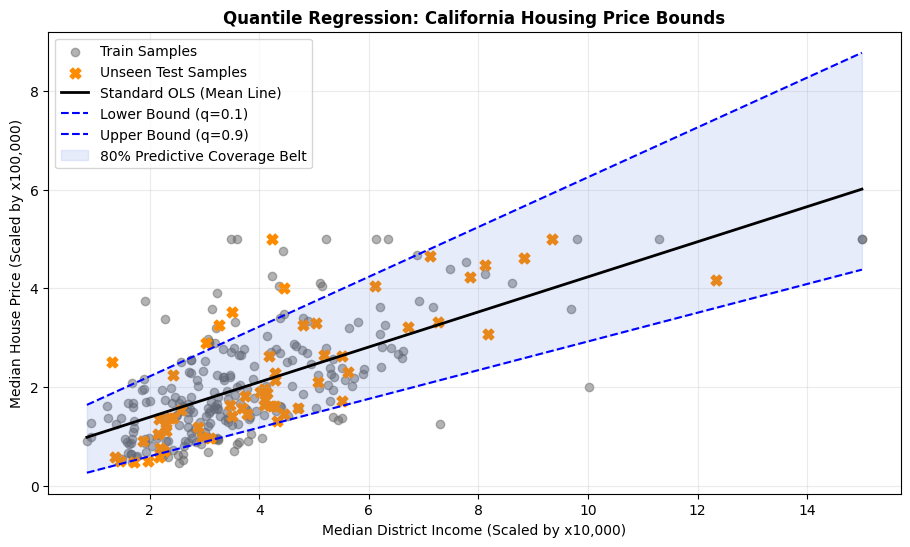

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
import statsmodels.formula.api as smf

# =====================================================================
# STEP 1: FETCH REAL DATASET & SUBSET FOR VISUALIZATION CLEARITY
# =====================================================================
# Load the official California Housing benchmark array
cali_data = fetch_california_housing(as_frame=True)
df_full = cali_data.frame

# We pull MedInc (Median Income in $10k blocks) vs MedHouseVal (House Price in $100k blocks)
df = df_full[['MedInc', 'MedHouseVal']].copy()

# Sample a clean batch (300 points) to visually isolate the boundary shifts cleanly
df = df.sample(n=300, random_state=42).reset_index(drop=True)

# Split into isolated training and testing arrays
df_train, df_test = train_test_split(df, test_size=0.2, random_state=42)
print(f"📊 Dataset successfully structured. Train units: {len(df_train)} | Test units: {len(df_test)}")

# =====================================================================
# STEP 2: BUILD DUAL QUANTILE AND STANDARD MEAN CORE MODELS
# =====================================================================
# Target allocations: 10th percentile (lower boundary), 90th percentile (upper boundary)
q_low = 0.10
q_high = 0.90

# Fit both independent Boundary Equations via Pinball Optimization
model_lower_bound = smf.quantreg("MedHouseVal ~ MedInc", df_train).fit(q=q_low)
model_upper_bound = smf.quantreg("MedHouseVal ~ MedInc", df_train).fit(q=q_high)

# For comparison, fit a traditional Ordinary Least Squares mean line
model_ols_mean = smf.ols("MedHouseVal ~ MedInc", df_train).fit()

# =====================================================================
# STEP 3: OUT-OF-SAMPLE INFERENCE ENGINE
# =====================================================================
def compute_housing_range(median_income_value):
    """
    Executes raw inference against an unseen income vector to isolate
    the estimated financial bracket window.
    """
    payload = pd.DataFrame({"MedInc": [median_income_value]})

    # Generate explicit point inferences
    low_est = model_lower_bound.predict(payload).iloc[0]
    high_est = model_upper_bound.predict(payload).iloc[0]
    mean_est = model_ols_mean.predict(payload).iloc[0]

    # Scale values back to actual dollar amounts ($100,000 baseline units)
    return {
        "Income_Input_Raw": round(median_income_value * 10000, 2),
        "Predicted_Mean_Price": round(mean_est * 100000, 2),
        "Lower_Price_Limit": round(low_est * 100000, 2),
        "Upper_Price_Limit": round(high_est * 100000, 2),
        "Total_Spread_Window": round((high_est - low_est) * 100000, 2)
    }

# Execute two distinct inference queries representing divergent socioeconomic zones
low_income_profile = compute_housing_range(median_income_value=2.5)   # $25,000 Avg Income
high_income_profile = compute_housing_range(median_income_value=7.0)  # $70,000 Avg Income

print("\n🔮 Production Inference Metrics:")
print(f"🔹 Low-Income Zone Bracket ($25k): Range is ${low_income_profile['Lower_Price_Limit']:,} to ${low_income_profile['Upper_Price_Limit']:,} (Spread: ${low_income_profile['Total_Spread_Window']:,})")
print(f"🔸 High-Income Zone Bracket ($70k): Range is ${high_income_profile['Lower_Price_Limit']:,} to ${high_income_profile['Upper_Price_Limit']:,} (Spread: ${high_income_profile['Total_Spread_Window']:,})")

# =====================================================================
# STEP 4: VISUAL GRAPHICAL PROOF OF EXTRACTED WINDOWS
# =====================================================================
# Build sequence spacing to sweep the plotting fields
x_sweep = pd.DataFrame({"MedInc": np.linspace(df["MedInc"].min(), df["MedInc"].max(), 200)})
sweep_low = model_lower_bound.predict(x_sweep)
sweep_high = model_upper_bound.predict(x_sweep)
sweep_mean = model_ols_mean.predict(x_sweep)

plt.figure(figsize=(11, 6))
plt.scatter(df_train["MedInc"], df_train["MedHouseVal"], color="dimgray", alpha=0.5, label="Train Samples")
plt.scatter(df_test["MedInc"], df_test["MedHouseVal"], color="darkorange", marker="X", s=60, label="Unseen Test Samples")

# Plot standard prediction paths
plt.plot(x_sweep["MedInc"], sweep_mean, color="black", linewidth=2, label="Standard OLS (Mean Line)")
plt.plot(x_sweep["MedInc"], sweep_low, color="blue", linestyle="--", label=f"Lower Bound (q={q_low})")
plt.plot(x_sweep["MedInc"], sweep_high, color="blue", linestyle="--", label=f"Upper Bound (q={q_high})")

# Shade the dynamic interval zone
plt.fill_between(x_sweep["MedInc"], sweep_low, sweep_high, color="royalblue", alpha=0.12, label="80% Predictive Coverage Belt")

plt.title("Quantile Regression: California Housing Price Bounds", fontsize=12, fontweight='bold')
plt.xlabel("Median District Income (Scaled by x10,000)")
plt.ylabel("Median House Price (Scaled by x100,000)")
plt.legend(loc="upper left")
plt.grid(True, alpha=0.25)
plt.show()
